In [9]:
source .venv/bin/activate
python -m pip uninstall prompt_toolkit
python -m pip install --upgrade prompt_toolkit

SyntaxError: invalid syntax (2347636960.py, line 2)

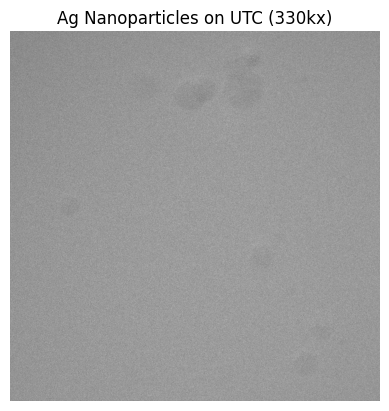

In [1]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_10.dm3")

data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']
plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.axis('off') 
plt.show()

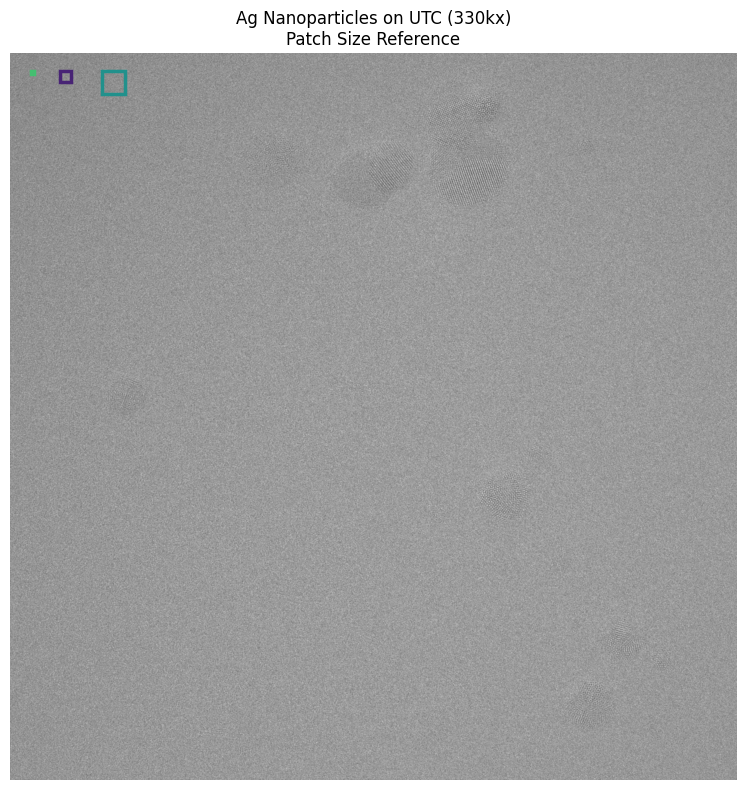

In [12]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

cmap = plt.get_cmap("viridis")
colors = [cmap(0.1), cmap(0.5), cmap(0.7)]  # RGBA tuples

file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_10.dm3")

data_dict = dm.dmReader(str(file.resolve()))
image_data = data_dict['data']

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_data, cmap='gray')

# (x, y, size, color)
patches = [
    (120, 100, 16, colors[2]),   # red
    (280, 100, 64, colors[0]),  # teal
    (520, 100, 128, colors[1]), # blue
]


for x, y, size, color in patches:
    ax.add_patch(Rectangle(
        (x, y),
        size,
        size,
        linewidth=2.5,
        edgecolor=color,
        facecolor='none'
    ))

ax.set_title("Ag Nanoparticles on UTC (330kx)\nPatch Size Reference")
ax.axis('off')
plt.tight_layout()
plt.show()

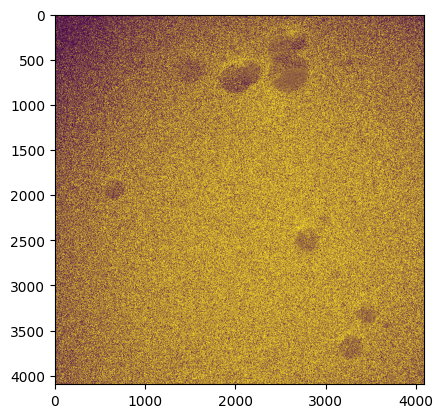

In [ ]:
import cv2
_, thresh_img = cv2.threshold(image_data, 700, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_img)

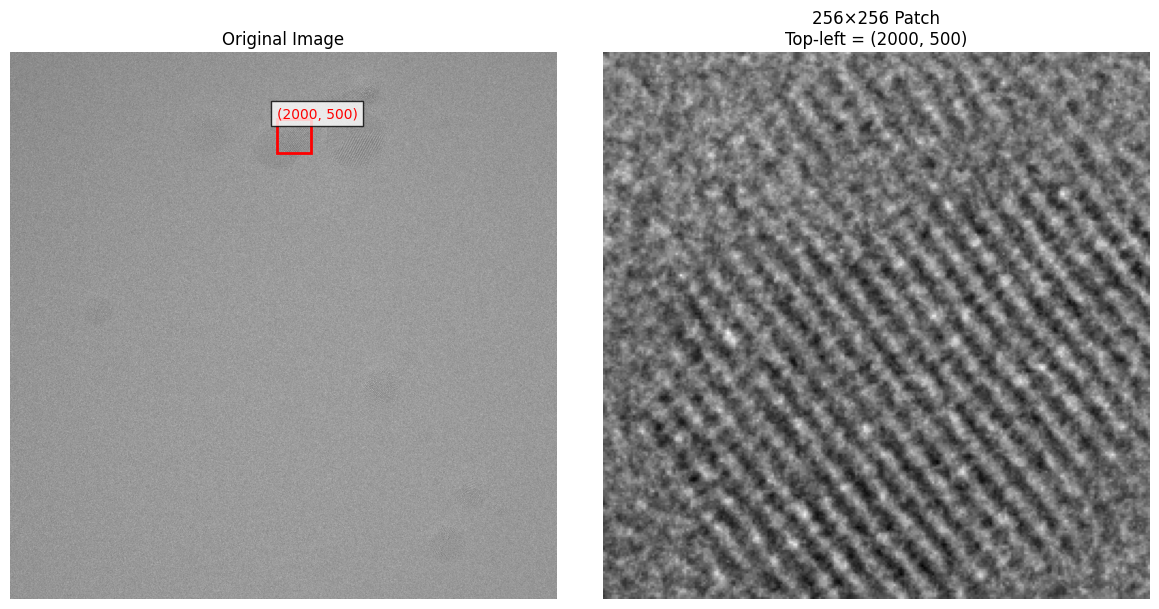

In [1]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# Load image
file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_10.dm3")
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']

# Patch parameters
patch_size = 256

# Choose patch location
# Option 1: specify coordinates
x = 2000   # column
y = 500   # row

# Option 2: random patch (uncomment instead)
# h, w = image_data.shape
# x = np.random.randint(0, w - patch_size + 1)
# y = np.random.randint(0, h - patch_size + 1)

# Ensure the patch fits inside the image
h, w = image_data.shape
x = min(max(0, x), w - patch_size)
y = min(max(0, y), h - patch_size)

# Extract patch
patch = image_data[y:y+patch_size, x:x+patch_size]

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original image
ax[0].imshow(image_data, cmap='gray')
ax[0].set_title("Original Image")

# Draw rectangle showing patch location
rect = Rectangle(
    (x, y),
    patch_size,
    patch_size,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)
ax[0].add_patch(rect)

# Label coordinates
ax[0].text(
    x,
    y - 10,
    f"({x}, {y})",
    color="red",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8)
)

ax[0].axis("off")

# Patch
ax[1].imshow(patch, cmap='gray')
ax[1].set_title(f"256×256 Patch\nTop-left = ({x}, {y})")
ax[1].axis("off")

plt.tight_layout()
plt.show()

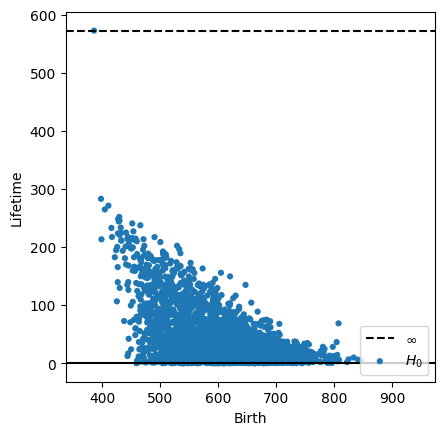

In [24]:
from persim import plot_diagrams
from ripser import lower_star_img
import matplotlib.pyplot as plt

dgm = lower_star_img(patch)

plot_diagrams(
    dgm,
    show=True,
    lifetime=True,      # birth vs death
    legend=True
)

In [28]:
print(dgm[0][:10])
print(dgm[0].shape)

[443.96084595 456.35168457]
(2,)


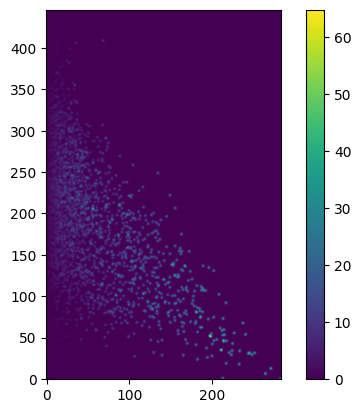

In [32]:
from persim import PersistenceImager
from persim import PersistenceImager

from persim import PersistenceImager
import numpy as np

diag = dgm                   # H0 diagram
diag = diag[np.isfinite(diag[:, 1])]   # remove points with death = inf

plt.imshow(pimg, origin="lower")
plt.colorbar()
plt.show()




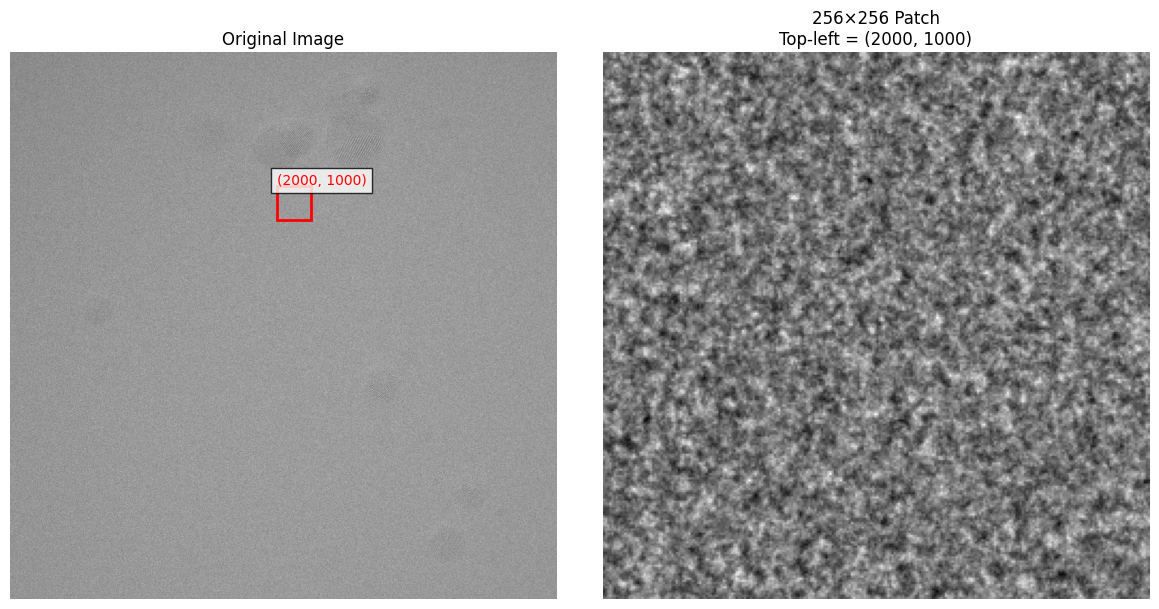

In [17]:

# Load image
file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_10.dm3")
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']

# Patch parameters
patch_size = 256

# Choose patch location
# Option 1: specify coordinates
x = 2000   # column
y = 1000   # row

# Option 2: random patch (uncomment instead)
# h, w = image_data.shape
# x = np.random.randint(0, w - patch_size + 1)
# y = np.random.randint(0, h - patch_size + 1)

# Ensure the patch fits inside the image
h, w = image_data.shape
x = min(max(0, x), w - patch_size)
y = min(max(0, y), h - patch_size)

# Extract patch
am_patch = image_data[y:y+patch_size, x:x+patch_size]

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original image
ax[0].imshow(image_data, cmap='gray')
ax[0].set_title("Original Image")

# Draw rectangle showing patch location
rect = Rectangle(
    (x, y),
    patch_size,
    patch_size,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)
ax[0].add_patch(rect)

# Label coordinates
ax[0].text(
    x,
    y - 10,
    f"({x}, {y})",
    color="red",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8)
)

ax[0].axis("off")

# Patch
ax[1].imshow(am_patch, cmap='gray')
ax[1].set_title(f"256×256 Patch\nTop-left = ({x}, {y})")
ax[1].axis("off")

plt.tight_layout()
plt.show()

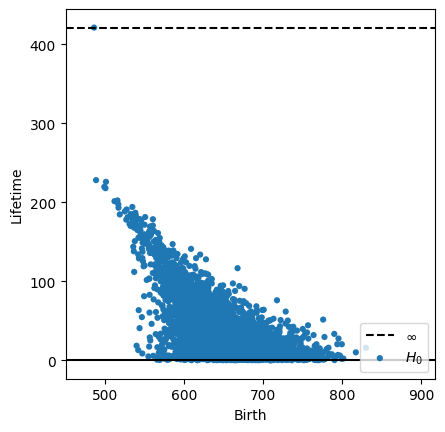

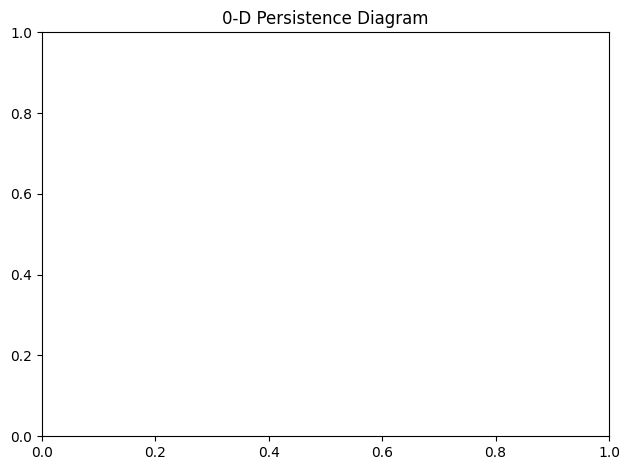

In [18]:
from persim import plot_diagrams
from ripser import lower_star_img

dgm = lower_star_img(am_patch)
plot_diagrams(
    dgm,
    show=True,
    lifetime=True,      # birth vs death
    legend=True
)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

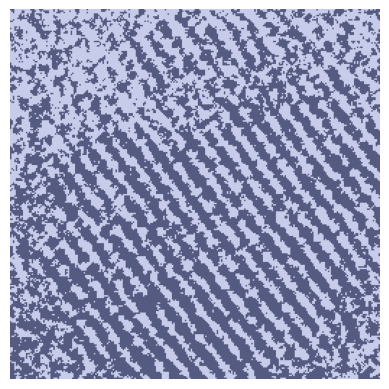

In [11]:
import cv2
_, threshold = cv2.threshold(patch, 700, 1284.2308, cv2.THRESH_BINARY)
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#555b80" ,

    "#c8cceb"  # background
      # foreground
])

plt.imshow(threshold > 0, cmap=cmap)
plt.axis("off")
plt.show()

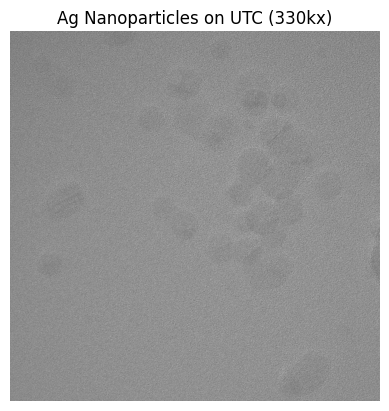

In [15]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_02.dm3")
label_file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels/20220202_Ag_UTC_330kx_2650e_0p1596s_02_label.png")

# Load the DM3 file
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']
plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.axis('off') 
plt.show()


In [24]:
print(image_data.dtype)
print(image_data.min(), image_data.max())

float32
0.0 1284.2308


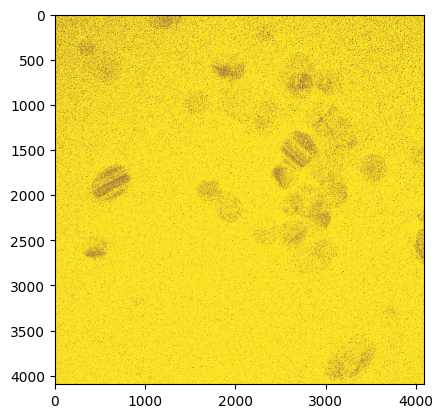

In [27]:
import cv2
_, threshold = cv2.threshold(image_data, 600, 1284.2308, cv2.THRESH_BINARY)
plt.imshow(threshold)

New Image, non-normalised

In [4]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("/home/eng-6770/Downloads/Ben_TEM/TEM/TEM,300kV,GL3S5,01Mar2022/ROI middle/UoSEbe5_middle_OA30_295kx_5.tif")

import tifffile
img = tifffile.imread(file)

In [5]:
from skimage.util import view_as_windows

def split_patches_and_positions(image, patch_size, stride):
    blocks = view_as_windows(image, window_shape=(patch_size, patch_size), step=stride)
    n_rows, n_cols = blocks.shape[:2]
    patches = blocks.reshape(-1, patch_size, patch_size)
    positions = [(i * stride, j * stride) for i in range(n_rows) for j in range(n_cols)]
    return patches, positions

patched_image, positions = split_patches_and_positions(img, 64, 16)

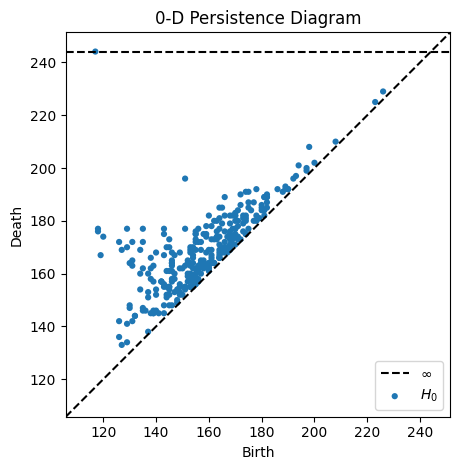

In [6]:
from ripser import lower_star_img
dgm = lower_star_img(patched_image[0])
from persim import plot_diagrams
plot_diagrams(dgm)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

In [15]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img
from persim import PersistenceImager
import numpy as np

pimgr = PersistenceImager(pixel_size=16)

def PH_patch(patched_image, scale_percentile=95):
    dgms = []
    for p in patched_image:
        dgm = lower_star_img(p)
        dgm = dgm[np.isfinite(dgm[:, 1])] 
        dgms.append(dgm)

    pimgr.fit(dgms)
    vectors = []
    for dgm in dgms:
        pimg = pimgr.transform(dgm)
        vec = pimg.ravel()
        vectors.append(vec)
    vectors = np.vstack(vectors)

    return dgms, vectors

dgms, vectorised_patches = PH_patch(patched_image)


In [14]:
print("vectorised_patches shape:", vectorised_patches.shape)
print("pimgr resolution:", pimgr.resolution)
print("pimgr birth_range:", pimgr.birth_range)
print("pimgr pers_range:", pimgr.pers_range)

# check if isfinite filter is actually working
all_deaths = np.concatenate([d[:, 1] for d in dgms if len(d) > 0])
print("any infinite deaths remaining:", np.any(np.isinf(all_deaths)))
print("death max (should be finite):", all_deaths[np.isfinite(all_deaths)].max())

vectorised_patches shape: (15625, 0)
pimgr resolution: (18, 0)
pimgr birth_range: (0.0, 300.0)
pimgr pers_range: (0.0, 1.0)
any infinite deaths remaining: False
death max (should be finite): 255.0


/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_15133/3331302418.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


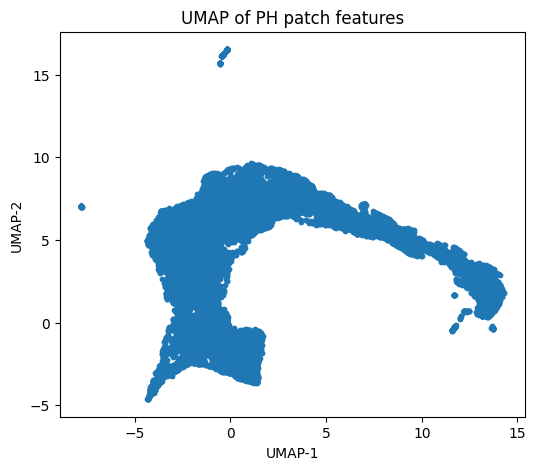

In [16]:
from sklearn.preprocessing import StandardScaler
import umap

X = StandardScaler().fit_transform(vectorised_patches)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding = reducer.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=10,
    cmap="Spectral"
)
plt.title("UMAP of PH patch features")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [17]:
def get_positions(image_data, window_shape, step):
    blocks = view_as_windows(image_data, window_shape, step)
    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * step, j * step)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions

In [18]:
import numpy as np

def label_to_image(original_image, labels, positions, patch_size, stride):

    H, W = original_image.shape[:2]
    unique_labels = np.unique(labels)
    label_to_idx = {lab: i for i, lab in enumerate(unique_labels)}
    n_labels = len(unique_labels)

    # vote_counts[k, r, c] = number of patches voting label k at pixel (r, c)
    vote_counts = np.zeros((n_labels, H, W), dtype=np.int32)

    for (r, c), lab in zip(positions, labels):
        r_end = min(r + patch_size, H)
        c_end = min(c + patch_size, W)
        k = label_to_idx[lab]
        vote_counts[k, r:r_end, c:c_end] += 1

    # pixels with no votes at all (gaps, if stride > patch_size) stay as background
    total_votes = vote_counts.sum(axis=0)
    winning_idx = np.argmax(vote_counts, axis=0)

    label_img = np.where(total_votes > 0, unique_labels[winning_idx], 0)

    return label_img

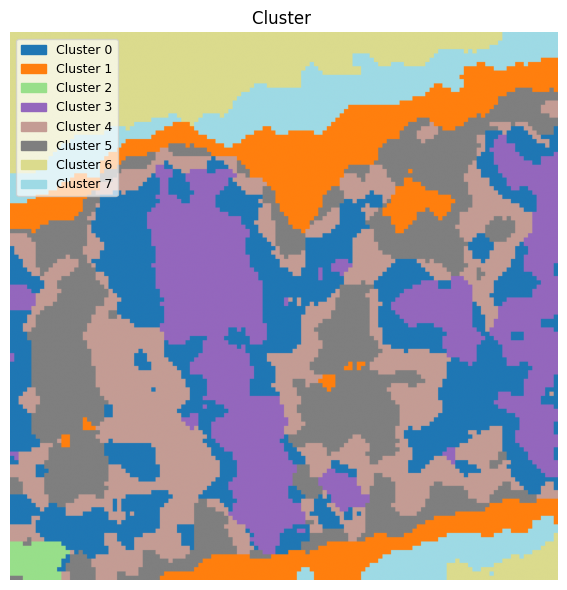

In [23]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=8, covariance_type="full")
labels = gmm.fit_predict(embedding)
positions = get_positions(img, (64,64), 16)
probs = gmm.predict_proba(embedding)

label_img = label_to_image(img, labels, positions, 64, 16)

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

plt.figure(figsize=(6,6))

clusters = np.unique(label_img)
cmap = plt.get_cmap("tab20", len(clusters))

plt.imshow(label_img, cmap=cmap)

plt.title("Cluster ")
plt.axis("off")

legend_patches = [
    mpatches.Patch(color=cmap(i), label=f"Cluster {c}")
    for i, c in enumerate(clusters)
]

plt.legend(
    handles=legend_patches,
    loc="upper left",          # inside plot
    frameon=True,             # box around legend
    framealpha=0.7,           # semi-transparent
    fontsize=9
)

plt.tight_layout()
plt.show()

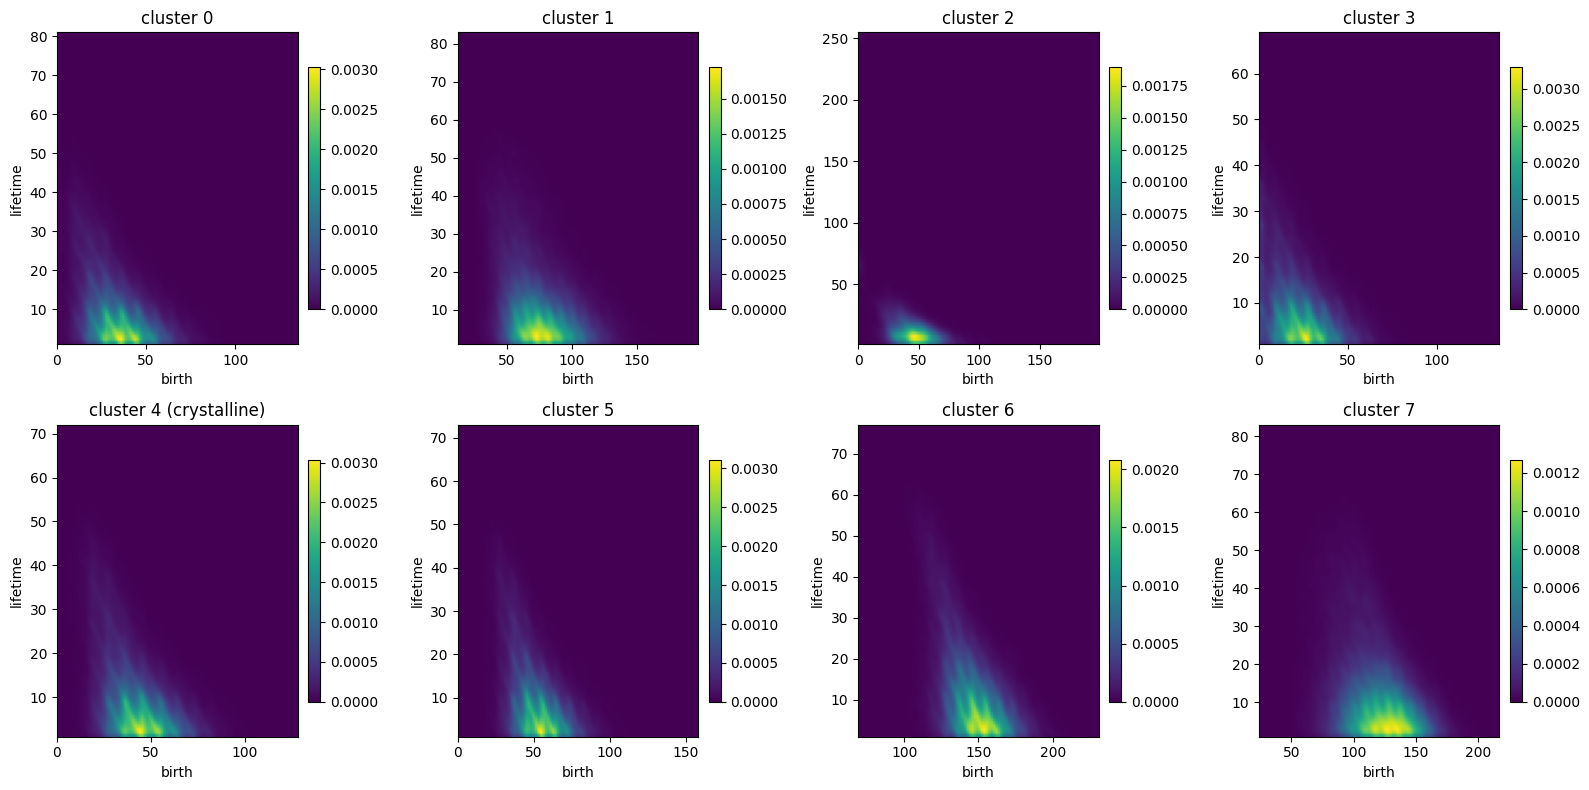

In [25]:
from scipy.stats import gaussian_kde

def cluster_persistence_density(dgms_in_cluster, grid_size=100, bw_method=None):
    all_points = np.vstack([d for d in dgms_in_cluster if len(d) > 0])
    births = all_points[:, 0]
    lifetimes = all_points[:, 1] - all_points[:, 0]

    coords = np.vstack([births, lifetimes])
    kde = gaussian_kde(coords, bw_method=bw_method)

    # evaluate on a grid for visualisation
    b_min, b_max = births.min(), births.max()
    l_min, l_max = lifetimes.min(), lifetimes.max()

    bb, ll = np.meshgrid(
        np.linspace(b_min, b_max, grid_size),
        np.linspace(l_min, l_max, grid_size)
    )
    grid_coords = np.vstack([bb.ravel(), ll.ravel()])
    density_grid = kde(grid_coords).reshape(grid_size, grid_size)

    return kde, density_grid, (b_min, b_max, l_min, l_max)

cluster_densities = {}
for label in np.unique(labels):
    indices = np.where(labels == label)[0]
    cluster_dgms = [dgms[i] for i in indices]
    kde, density_grid, extent = cluster_persistence_density(cluster_dgms)
    cluster_densities[label] = (density_grid, extent)

n_clusters = len(cluster_densities)
n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (label, (density_grid, extent)) in zip(axes, cluster_densities.items()):
    im = ax.imshow(density_grid, origin='lower', extent=extent, aspect='auto', cmap='viridis')
    ax.set_title(f"cluster {label}" + (" (crystalline)" if label == 4 else ""))
    ax.set_xlabel("birth")
    ax.set_ylabel("lifetime")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# hide any unused subplot axes
for ax in axes[len(cluster_densities):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

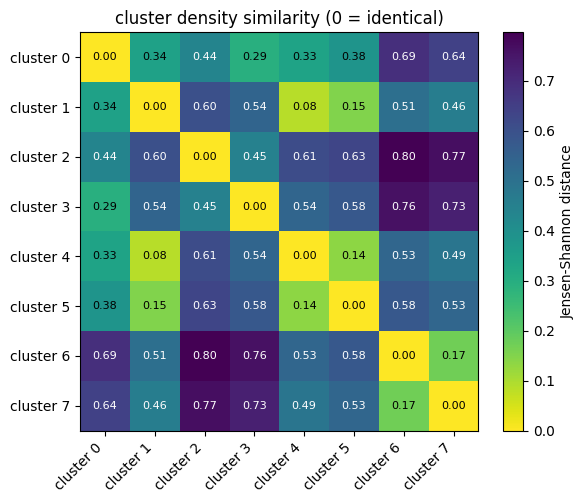

In [26]:
from scipy.spatial.distance import jensenshannon

def normalise_density(density_grid, eps=1e-10):
    flat = density_grid.ravel()
    flat = np.clip(flat, 0, None)
    flat = flat + eps
    return flat / flat.sum()

labels_sorted = sorted(cluster_densities.keys())
n = len(labels_sorted)

similarity_matrix = np.zeros((n, n))

for i, li in enumerate(labels_sorted):
    for j, lj in enumerate(labels_sorted):
        di = normalise_density(cluster_densities[li][0])
        dj = normalise_density(cluster_densities[lj][0])
        similarity_matrix[i, j] = jensenshannon(di, dj)  # 0 = identical, 1 = maximally different

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(similarity_matrix, cmap='viridis_r', vmin=0, vmax=similarity_matrix.max())

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"cluster {l}" for l in labels_sorted], rotation=45, ha='right')
ax.set_yticklabels([f"cluster {l}" for l in labels_sorted])

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{similarity_matrix[i,j]:.2f}", ha='center', va='center',
                 color='white' if similarity_matrix[i,j] > similarity_matrix.max()/2 else 'black',
                 fontsize=8)

fig.colorbar(im, label="Jensen-Shannon distance")
plt.title("cluster density similarity (0 = identical)")
plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def compute_fft_magnitude(patch):
    f = np.fft.fftshift(np.fft.fft2(patch))
    magnitude = np.log(np.abs(f) + 1)  # log scale — makes peaks visible against background
    return magnitude

# 1. Compute FFT magnitude for every patch once, store alongside existing data
fft_magnitudes = np.array([compute_fft_magnitude(p) for p in patched_image])  # (n_patches, H, W)
print(fft_magnitudes.shape)

(15625, 64, 64)


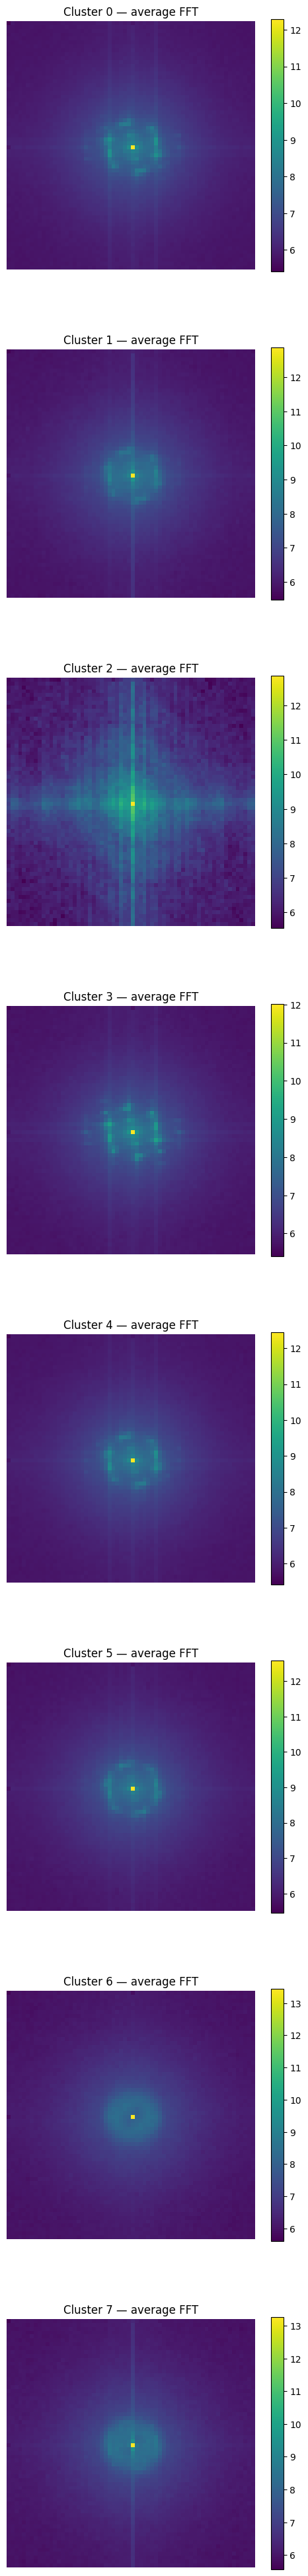

In [28]:
cluster_avg_fft = {}
cluster_labels_sorted = sorted(np.unique(labels))
for label in cluster_labels_sorted:
    idx = np.where(labels == label)[0]
    cluster_avg_fft[label] = fft_magnitudes[idx].mean(axis=0)

fig, axes = plt.subplots(n, 1, figsize=(5, 5*n))
if n == 1:
    axes = [axes]

for ax, label in zip(axes, cluster_labels_sorted):
    im = ax.imshow(cluster_avg_fft[label])
    ax.set_title(f"Cluster {label} — average FFT")
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

In [ ]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("/home/eng-6770/Downloads/Ben_TEM/TEM/TEM,300kV,GL3S5,01Mar2022/ROI middle/UoSEbe5_middle_OA30_295kx_5.tif")

import tifffile
img = tifffile.imread(file)
print(img.shape, img.dtype)